## Visualizing Function Dependencies

In [1]:
from functiongraph import FunctionGraph

Setting up clang library...
Checking /usr/lib/llvm-18/lib...
Found libclang.so in /usr/lib/llvm-18/lib
Successfully initialized clang


In [2]:
graph = FunctionGraph("./tmp/adiprerepa/cs598APE-hw1/")

RuntimeError: Function '' not found in codebase

In [ ]:
{node:list(graph.predecessors(node)) for node in graph.nodes if 'getIntersection' in node}

{'./tmp/adiprerepa/cs598APE-hw1/src/disk.cpp/Disk::getIntersection': [],
 './tmp/adiprerepa/cs598APE-hw1/src/box.cpp/Box::getIntersection': [],
 './tmp/adiprerepa/cs598APE-hw1/src/triangle.cpp/Triangle::getIntersection': [],
 './tmp/adiprerepa/cs598APE-hw1/src/sphere.cpp/Sphere::getIntersection': [],
 './tmp/adiprerepa/cs598APE-hw1/src/plane.cpp/Plane::getIntersection': ['./tmp/adiprerepa/cs598APE-hw1/src/disk.cpp/Disk::getIntersection',
  './tmp/adiprerepa/cs598APE-hw1/src/box.cpp/Box::getIntersection',
  './tmp/adiprerepa/cs598APE-hw1/src/triangle.cpp/Triangle::getIntersection']}

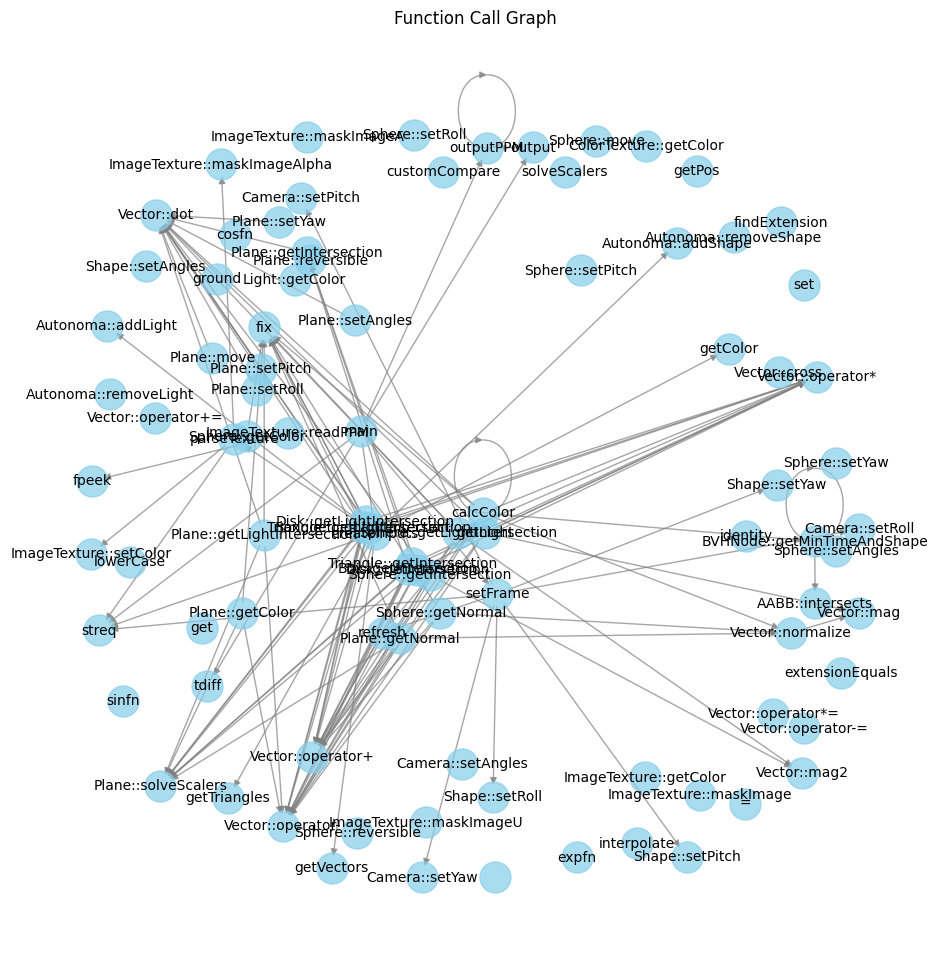

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

def visualize_function_graph(graph):
    """
    Visualizes the function call graph using matplotlib and networkx.
    The nodes represent function calls, and edges represent calling relationships.
    The function labels are simplified to just 'Class::Function' or 'Function' without the path.
    """
    plt.figure(figsize=(12, 12))
    
    # Prepare the labels with just 'Class::Function' or 'Function' without the path
    labels = {}
    for node in graph.nodes:
        # Extract class name and function name, if applicable, and set it as label
        label = node.split('/')[-1]  # Extract the last part of the path (Class::Function or Function)
        labels[node] = label
    
    # Draw the graph
    pos = nx.spring_layout(graph, k=0.15, iterations=20)  # Use a spring layout for node positioning
    
    # Draw nodes and edges
    nx.draw_networkx_nodes(graph, pos, node_size=500, node_color="skyblue", alpha=0.7)
    nx.draw_networkx_edges(graph, pos, width=1.0, alpha=0.7, edge_color="gray")
    nx.draw_networkx_labels(graph, pos, labels=labels, font_size=10, font_color="black")
    
    plt.title("Function Call Graph")
    plt.axis('off')  # Hide the axis
    plt.show()

# Example usage:
visualize_function_graph(graph)


In [ ]:
ranked = nx.pagerank(graph)
# print top 10 functions
sorted(ranked.items(), key=lambda x: x[1], reverse=True)[:10]

[('./tmp/adiprerepa/cs598APE-hw1/main.cpp/outputPPM', 0.10531563473685045),
 ('./tmp/adiprerepa/cs598APE-hw1/src/vector.cpp/Vector::dot',
  0.059559860035617515),
 ('./tmp/adiprerepa/cs598APE-hw1/src/vector.cpp/Vector::operator-',
  0.02689713315867368),
 ('./tmp/adiprerepa/cs598APE-hw1/src/Textures/texture.cpp/fix',
  0.025851410550137663),
 ('./tmp/adiprerepa/cs598APE-hw1/src/vector.cpp/Vector::operator+',
  0.02553815638806195),
 ('./tmp/adiprerepa/cs598APE-hw1/src/plane.cpp/Plane::solveScalers',
  0.019494040002554985),
 ('./tmp/adiprerepa/cs598APE-hw1/src/vector.cpp/Vector::mag',
  0.018754965302639735),
 ('./tmp/adiprerepa/cs598APE-hw1/src/vector.cpp/Vector::operator*',
  0.01818994747468104),
 ('./tmp/adiprerepa/cs598APE-hw1/src/bvh.cpp/BVHNode::getMinTimeAndShape',
  0.015043016348394996),
 ('./tmp/adiprerepa/cs598APE-hw1/src/aabb.cpp/AABB::intersects',
  0.013888720172954257)]